In [4]:
import pandas as pd

# Load full dataset
train = pd.read_csv("../data/raw/train.csv")

# Convert date column to datetime
train['date'] = pd.to_datetime(train['date'], format='%Y-%m-%d')

# Check dataset date range
print("Start Date:", train['date'].min())
print("End Date:", train['date'].max())

# Display first 5 rows
train.head()

Start Date: 2013-01-01 00:00:00
End Date: 2017-08-15 00:00:00


,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0


In [5]:
# Aggregate total daily sales
daily_sales = train.groupby('date')['sales'].sum().reset_index()

# Rename columns for Prophet
daily_sales.columns = ['ds', 'y']

# Display first rows
daily_sales.head()

,ds,y
0,2013-01-01,2511.618999
1,2013-01-02,496092.417944
2,2013-01-03,361461.231124
3,2013-01-04,354459.677093
4,2013-01-05,477350.121229


In [6]:
from prophet import Prophet

Importing plotly failed. Interactive plots will not work.


In [7]:
# Create Prophet model
model = Prophet()

# Train model
model.fit(daily_sales)

22:56:27 - cmdstanpy - INFO - Chain [1] start processing
22:56:28 - cmdstanpy - INFO - Chain [1] done processing


In [8]:
# Create future dates for next 90 days
future = model.make_future_dataframe(periods=90)

# Predict future sales
forecast = model.predict(future)

# Display forecast results
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail()

,ds,yhat,yhat_lower,yhat_upper
1769,2017-11-09,7.982999e+05,661661.068435,9.332095e+05
1770,2017-11-10,8.739563e+05,749113.245143,1.019258e+06
1771,2017-11-11,1.065455e+06,927455.999745,1.201898e+06
1772,2017-11-12,1.119719e+06,979567.041956,1.264856e+06
1773,2017-11-13,9.096974e+05,769658.007527,1.053340e+06


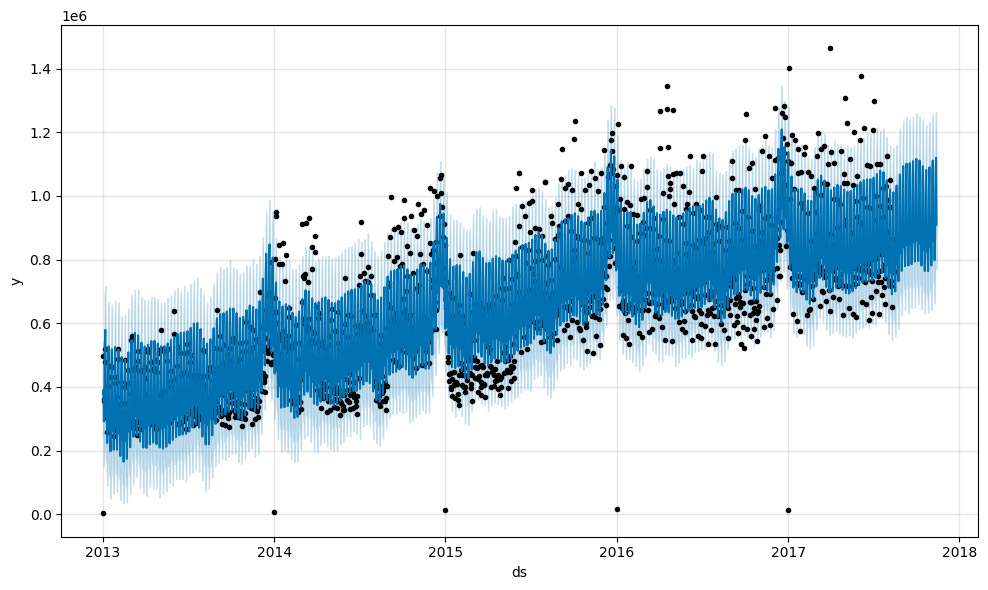

In [9]:
# Forecast Graph

fig1 = model.plot(forecast)

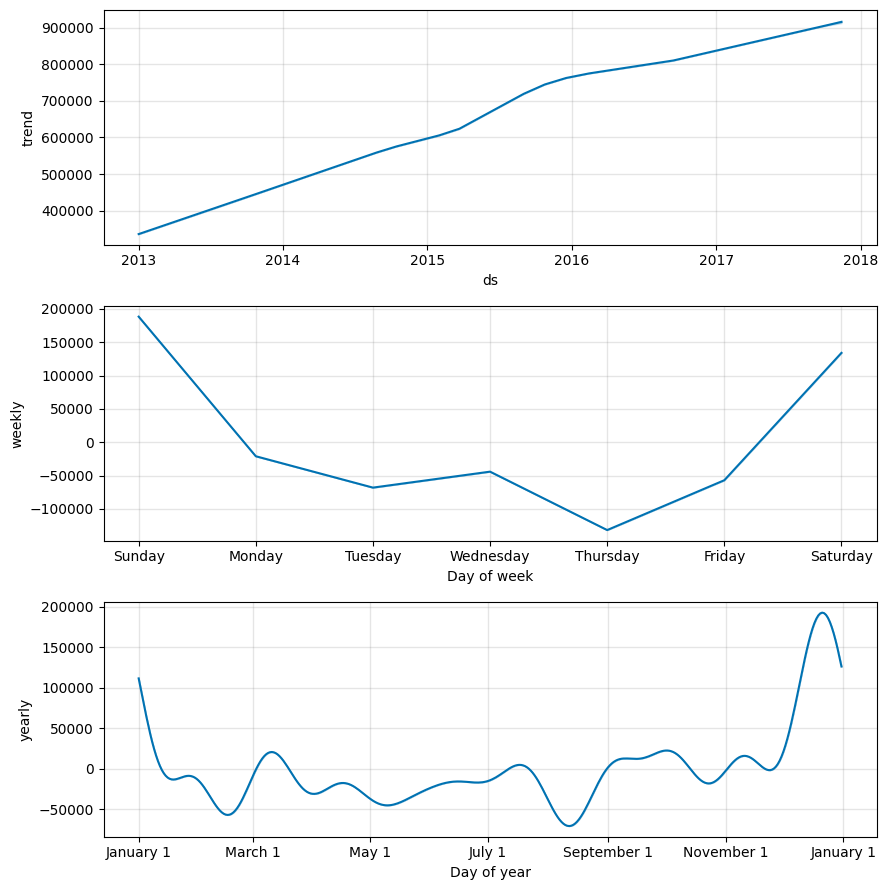

In [10]:
# Prophet Components Graph

fig2 = model.plot_components(forecast)

In [11]:
# Export Forecast Results

forecast_output = forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']]

forecast_output.to_csv("../outputs/grocery_sales_forecast.csv", index=False)

print("Forecast CSV Exported Successfully!")

Forecast CSV Exported Successfully!


In [12]:
# Check Missing Values

train.isnull().sum()

id             0
date           0
store_nbr      0
family         0
sales          0
onpromotion    0
dtype: int64

In [13]:
# Check Duplicate Rows

train.duplicated().sum()

np.int64(0)

In [14]:
# Dataset Information

train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 6 columns):
 #   Column       Dtype         
---  ------       -----         
 0   id           int64         
 1   date         datetime64[ns]
 2   store_nbr    int64         
 3   family       object        
 4   sales        float64       
 5   onpromotion  int64         
dtypes: datetime64[ns](1), float64(1), int64(3), object(1)
memory usage: 137.4+ MB


In [15]:
# Statistical Summary

train.describe()

,id,date,store_nbr,sales,onpromotion
count,3.000888e+06,3000888,3.000888e+06,3.000888e+06,3.000888e+06
mean,1.500444e+06,2015-04-24 08:27:04.703088384,2.750000e+01,3.577757e+02,2.602770e+00
min,0.000000e+00,2013-01-01 00:00:00,1.000000e+00,0.000000e+00,0.000000e+00
25%,7.502218e+05,2014-02-26 18:00:00,1.400000e+01,0.000000e+00,0.000000e+00
50%,1.500444e+06,2015-04-24 12:00:00,2.750000e+01,1.100000e+01,0.000000e+00
75%,2.250665e+06,2016-06-19 06:00:00,4.100000e+01,1.958473e+02,0.000000e+00
max,3.000887e+06,2017-08-15 00:00:00,5.400000e+01,1.247170e+05,7.410000e+02
std,8.662819e+05,NaN,1.558579e+01,1.101998e+03,1.221888e+01


In [16]:
# Verify Date Range

print("Start Date:", train['date'].min())
print("End Date:", train['date'].max())

Start Date: 2013-01-01 00:00:00
End Date: 2017-08-15 00:00:00


In [17]:
# Check Negative Sales

(train['sales'] < 0).sum()

np.int64(0)